In [ ]:
# Homework 9

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [4]:
df = pd.read_csv('/Users/keatondiehl/python_decal_fa25/course_assignments/homework9/noisy_curvefit_data.csv')

In [7]:
df.shape
# 100 rows
# 6 columns
# x,	y_noise_1,	y_noise_2,	y_noise_3,	y_noise_4,	y_noise_5

(100, 6)

In [8]:
df.head()

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113


In [9]:
df.tail()

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548
99,6.000000,-0.193438,-2.244792,1.930035,4.992414,-6.872850


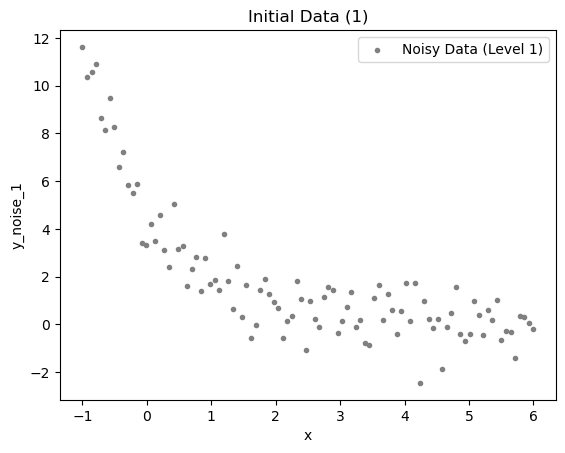

In [24]:
x = df['x']
y1 = df['y_noise_1']
plt.figure()
plt.scatter(x, y1, label='Noisy Data (Level 1)', color='gray', marker='.')
plt.title('Initial Data (1)')
plt.xlabel('x')
plt.ylabel('y_noise_1')
plt.legend()
plt.show()

In [25]:
def model(x, A, k):
    return A * np.exp(-k * x)

In [26]:
p0 = [1, 1]
popt, pcov = curve_fit(model, x, y1, p0=p0)
# print(popt, pcov)

In [34]:
A_fit_1, k_fit_1 = popt

In [35]:
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

Fit: y = 4.71 * e^(-0.92 * x)


In [36]:
residuals = y1 - model(x, A_fit_1, k_fit_1)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced_1 = chi2 / dof
print(chi2_reduced_1)

0.7906732087457324


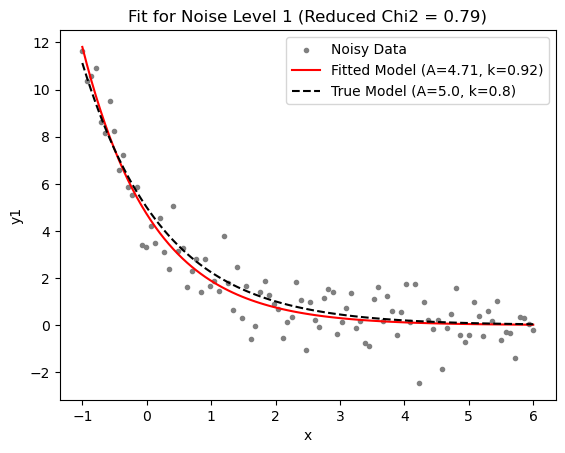

In [37]:
A_true, k_true = 5.0, 0.8
x_model = np.linspace(min(x), max(x), 100)

plt.figure()
plt.scatter(x, y1, label='Noisy Data', color='gray', marker='.')

plt.plot(x_model, model(x_model, A_fit_1, k_fit_1), 'r-', label=f'Fitted Model (A={A_fit_1:.2f}, k={k_fit_1:.2f})')
# True model
plt.plot(x_model, model(x_model, A_true, k_true), 'k--', label=f'True Model (A={A_true}, k={k_true})')

plt.title(f'Fit for Noise Level 1 (Reduced Chi2 = {chi2_reduced_1:.2f})')
plt.xlabel('x')
plt.ylabel('y1')
plt.legend()
plt.show()

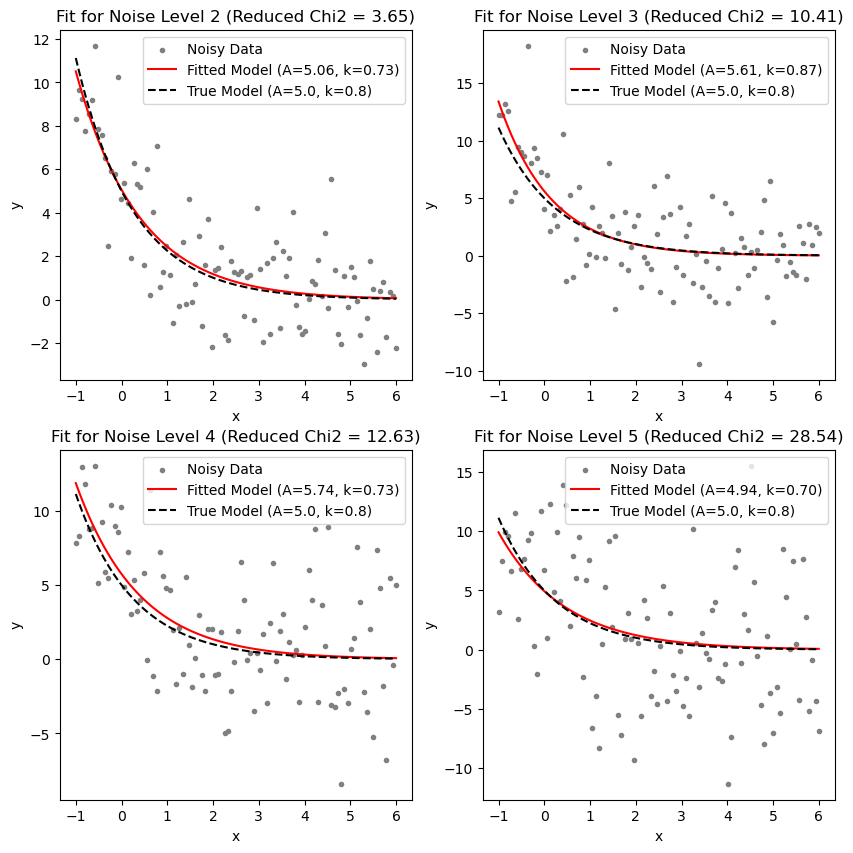

In [48]:
def fit_model(x, y):
    popt, pcov = curve_fit(model, x, y, p0=[1.0, 1.0])
    
    n = len(x)
    p = len(popt)
    dof = n - p
    residuals = y - model(x, *popt)
    chi2 = np.sum(residuals**2)
    chi2_reduced = chi2 / dof
    
    return popt, chi2_reduced

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()

results_list = [
    {
        'Noise Level': 1,
        'A_fit': A_fit_1,
        'k_fit': k_fit_1,
        'Reduced Chi-Squared': chi2_reduced_1
    }
]

for i in range(2, 6):
    noise_level = i
    y_column = f'y_noise_{noise_level}'

    ax = axs[i-2]

    y = df[y_column]
    popt, chi2_reduced = fit_model(df['x'], y)
    A_fit, k_fit = popt
    
    results_list.append({
        'Noise Level': noise_level,
        'A_fit': A_fit,
        'k_fit': k_fit,
        'Reduced Chi-Squared': chi2_reduced
    })

    ax.scatter(df['x'], y, label='Noisy Data', color='gray', marker='.')
    
    ax.plot(x_model, model(x_model, A_fit, k_fit), 'r-', label=f'Fitted Model (A={A_fit:.2f}, k={k_fit:.2f})')
   
    ax.plot(x_model, model(x_model, A_true, k_true), 'k--', label=f'True Model (A={A_true}, k={k_true})')
    
    ax.set_title(f'Fit for Noise Level {noise_level} (Reduced Chi2 = {chi2_reduced:.2f})')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
plt.show()

In [ ]:
# As noise level increases, the noisy data becomes more scattered and the chi2 value increases rapidly. 
        # This is because there is more variance between each point and the fitted model.
# Moreover, the fitted model continues to show divergance from the true model no matter the noise level.

In [50]:
results_df = pd.DataFrame(results_list)
results_df.shape

(5, 4)

In [54]:
print(results_df)

   Noise Level     A_fit     k_fit  Reduced Chi-Squared
0            1  4.714814  0.918308             0.790673
1            2  5.063889  0.730396             3.649382
2            3  5.609396  0.870372            10.410207
3            4  5.738727  0.725965            12.626832
4            5  4.943458  0.695012            28.538124


In [57]:
results_df.to_csv('noisy_parameters.csv', index = False)